# Solución Control 1 - Fundamentos de Machine Learning

## Pregunta 1: Clasificación con k-NN y Visualización t-SNE

### 1.a Clasificador k-NN en Fashion-MNIST

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# Carga del dataset
X, y = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)
X = X / 255.0  # Normalización
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Clasificador k-NN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.75      0.87      0.81      1394
           1       0.99      0.97      0.98      1402
           2       0.72      0.80      0.76      1407
           3       0.91      0.84      0.87      1449
           4       0.79      0.76      0.77      1357
           5       1.00      0.84      0.91      1449
           6       0.69      0.60      0.64      1407
           7       0.88      0.95      0.92      1359
           8       0.98      0.95      0.96      1342
           9       0.89      0.96      0.93      1434

    accuracy                           0.86     14000
   macro avg       0.86      0.86      0.86     14000
weighted avg       0.86      0.86      0.86     14000



### 1.b Visualización con t-SNE y análisis de clusters

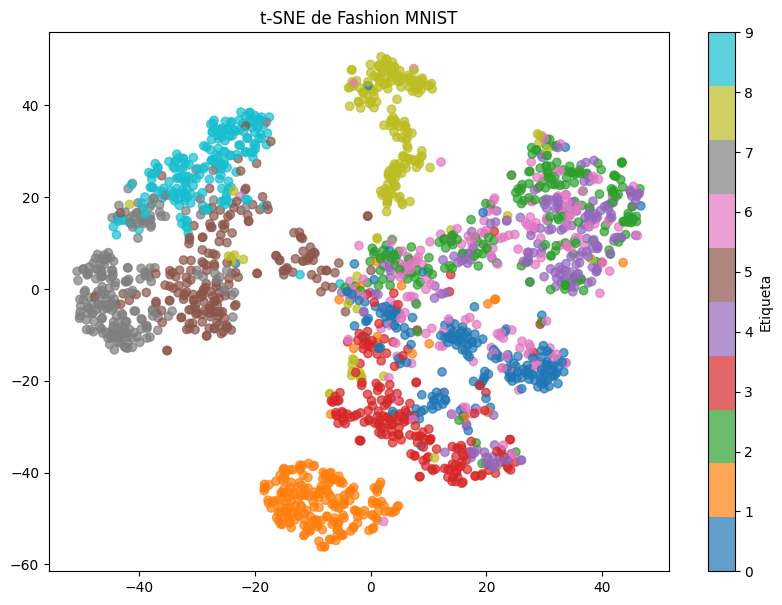

In [2]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reducimos el tamaño del dataset para visualización
X_small = X[:2000]
y_small = y[:2000]

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_small)

# Visualización
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_small.astype(int), cmap='tab10', alpha=0.7)
plt.title('t-SNE de Fashion MNIST')
plt.colorbar(scatter, label='Etiqueta')
plt.show()


### 1.c Evaluación con distintas configuraciones de k

In [3]:
import numpy as np
from sklearn.metrics import accuracy_score

ks = [1, 3, 5, 7, 9]
accuracies = []

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    accuracies.append(acc)

for k, acc in zip(ks, accuracies):
    print(f"k={k}: Accuracy={acc:.4f}")


k=1: Accuracy=0.8536
k=3: Accuracy=0.8559
k=5: Accuracy=0.8568
k=7: Accuracy=0.8567
k=9: Accuracy=0.8549


## Pregunta 2: Modelos de Árboles y Explicabilidad

### 2.a Entrenamiento de árboles con validación cruzada

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

params = [3, 5, 10, None]
for d in params:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    scores = cross_val_score(clf, X_train, y_train, cv=5)
    print(f"Max depth={d}: Cross-val Accuracy={np.mean(scores):.4f}")


Max depth=3: Cross-val Accuracy=0.4987
Max depth=5: Cross-val Accuracy=0.7049
Max depth=10: Cross-val Accuracy=0.8065
Max depth=None: Cross-val Accuracy=0.7883


### 2.b Análisis de importancia de variables

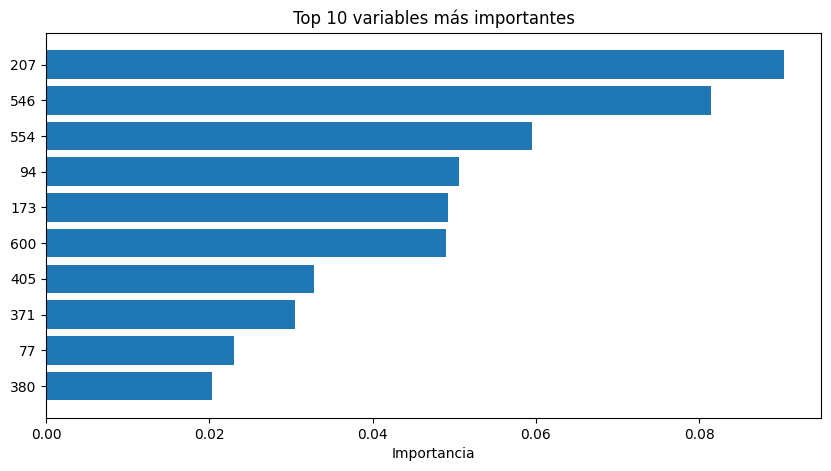

In [5]:
importances = clf.fit(X_train, y_train).feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10,5))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), indices)
plt.xlabel('Importancia')
plt.title('Top 10 variables más importantes')
plt.show()


### Pregunta 2c

Para obtener los mejores hiperparámetros de un árbol de regresión en un conjunto de datos pequeño, una estrategia recomendada es:

#### Validación cruzada con búsqueda en malla (Grid Search):
Esta técnica permite probar combinaciones de hiperparámetros en distintos folds del dataset para obtener una estimación robusta de su rendimiento.


In [6]:

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# Supongamos que X e y ya están definidos
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

tree = DecisionTreeRegressor(random_state=42)
grid_search = GridSearchCV(tree, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X, y)

print("Mejores parámetros:", grid_search.best_params_)



Mejores parámetros: {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10}


#### Consideraciones:
- Se recomienda usar `cv=LeaveOneOut()` o `cv=5` si el dataset es muy pequeño.
- Para ahorrar recursos, también se puede usar **RandomizedSearchCV** si hay muchas combinaciones posibles.


## Pregunta 3: Pregunta teórica sobre k-NN y t-SNE

### Pregunta 3

**a) ¿Cuál es el efecto que producen en los modelos de ML vistos hasta ahora, los ejemplos repetidos en un set de datos? Analice de manera independiente para cada uno de ellos.**

- **k-NN:** Los ejemplos repetidos refuerzan su influencia, ya que aumentan la probabilidad de ser vecinos cercanos. Esto puede sesgar la predicción, especialmente si hay clases desbalanceadas.
- **Árboles de decisión:** Los ejemplos repetidos influyen en la elección de splits al dominar estadísticas como la ganancia de información, lo cual puede llevar al sobreajuste si el modelo aprende a memorizar esos ejemplos.
- **Regresión lineal o árboles de regresión:** Al igual que en clasificación, los ejemplos repetidos pueden actuar como "pesos" más altos, influyendo desproporcionadamente en el ajuste del modelo.

---

**b) ¿Cómo combinaría los resultados de dos modelos distintos entrenados para la misma tarea sobre los mismos datos, de modo de generar un mejor modelo?**

- Mediante técnicas de **ensamblado**:
  - **Voting (clasificación):** Se combina la predicción de múltiples clasificadores por mayoría o probabilidad promedio.
  - **Averaging (regresión):** Se promedian las predicciones numéricas.
  - **Stacking:** Entrenar un modelo adicional que aprenda a combinar las salidas de los modelos base.

---

**c) ¿Cómo obtendría los mejores hiperparámetros para un árbol de regresión (profundidad máxima, por ejemplo), si posee un conjunto de datos pequeño?**

- Usaría técnicas de validación que aprovechen al máximo el dataset:
  - **Validación cruzada Leave-One-Out (LOOCV)** o k-fold con pocos pliegues.
  - Utilizar **Grid Search** o **Random Search** con un espacio de hiperparámetros restringido.
  - Considerar métodos bayesianos como **Bayesian Optimization** si se desea eficiencia.

---

**d) ¿Por qué motivo los árboles de decisión particionan este espacio de características mediante líneas rectas paralelas a los ejes?**

- Porque los árboles dividen el espacio en función de un único atributo a la vez.
- Esto genera **hiperplanos ortogonales** a los ejes, lo que en 2D se traduce en **rectas paralelas a los ejes**.
- Este enfoque permite una interpretación simple y eficiente del espacio de decisión.

---

**e) ¿Cómo se debería modificar un árbol de decisión para que genere particiones basadas en rectas con pendiente arbitraria (no necesariamente ortogonales a los ejes)?**

- Se deben usar modelos de **árboles oblicuos**, donde los nodos usan combinaciones lineales de atributos.
- El criterio de partición sería del tipo \( w^T x + b = 0 \), permitiendo divisiones diagonales o arbitrarias.
- Otra alternativa sería combinar árboles con modelos como SVM o redes neuronales para permitir decisiones más flexibles.

---

**f) ¿Qué métrica de distancia debiese usarse si se utiliza un algoritmo de k-NN para la clasificación de estos puntos sobre una hiperesfera en \( \mathbb{R}^{10} \)?**

- La **distancia del coseno** es más adecuada, ya que los puntos están sobre una hiperesfera (todos con la misma norma).
- La **distancia euclidiana** pierde poder discriminativo en altas dimensiones con vectores normalizados.
- La distancia angular preserva mejor la relación de similitud entre vectores en este contexto.
